In [1]:
import numpy as np
from helpers import *
import matplotlib.pyplot as plt
import tqdm
import pandas as pd

2025-12-09 14:02:43.963 | INFO     | time_series.config:<module>:13 - PROJ_ROOT path is: /home/james/Repo/PhD Repo/time_series_clustering
/home/james/Repo/PhD Repo/time_series_clustering/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sklearn.model_selection import KFold

In [3]:
from collections import defaultdict

In [4]:
def mean_squared_error_cv(x, y, model, nfolds=5):
    kf = KFold(n_splits=nfolds, random_state=None, shuffle=False)
    scores = []
    
    for i, (train_index, test_index) in enumerate(kf.split(x)):
        X_train = x[train_index]
        X_test = x[test_index]

        y_train = y[train_index]
        y_test = y[test_index] 

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        score = mean_squared_error(y_test, y_pred)
        scores.append(score)
    return np.mean(scores)

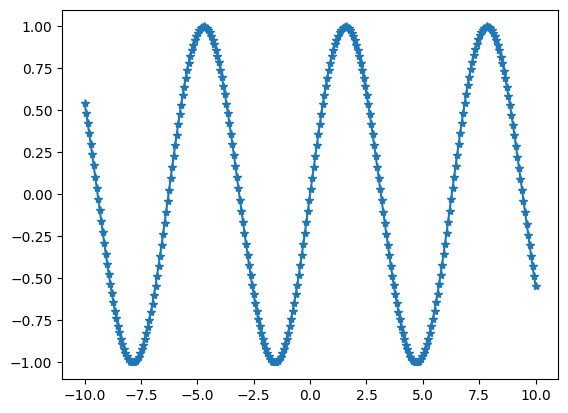

In [5]:
f = lambda x: np.sin(x)

x = np.linspace(-10, 10, 300)
y = f(x)

plt.plot(x, y, "-*")

In [ ]:
def pairwise_paramsearch(x1, y1, x2, y2, ntrials=30):
    def objective(trial):
        bandwidth = trial.suggest_float("bandwidth", 1e-9, 4)
        reg1 = trial.suggest_float("reg1", 1e-12, 1e-2)
        reg2 = trial.suggest_float("reg2", 1e-12, 1e-2)

        model1 = KRRWrapper(bandwidth, reg1)
        model2 = KRRWrapper(bandwidth, reg2)

        return mean_squared_error_cv(x1, y1, model1) + mean_squared_error_cv(x2, y2, model2)
    
    study = optuna.create_study()
    study.optimize(objective, n_trials=ntrials)

    return study.best_params

In [16]:
noise = 0.1

paramsearch = OptunaHyperparameterTuning(
    KRRWrapper,
    param_grid={
        "bandwidth": dict(type="float", min=1e-9, max=4),
        "reg": dict(type="float", min=1e-12, max=1e-2)
    },
    scoring=mean_squared_error,
    n_trials=100
)

# DS 1
y1 = f(x) + noise*np.random.normal(0, 1, len(x))
paramsearch.fit(x, y1)
b1, r1 = paramsearch.best_params.values()

model1 = KRRWrapper(b1, r1)
print("model 1: ", mean_squared_error_cv(x, y, model1))

# DS 2
y2 = f(2*x) + noise*np.random.normal(0, 1, len(x))
paramsearch.fit(x, y2)
b2, r2 = paramsearch.best_params.values()

model2 = KRRWrapper(b2, r2)
print("model 2: ", mean_squared_error_cv(x, y, model2))

model 1:  0.055033000213589686
model 2:  0.34463510250723495


In [18]:
best_pairwise_params = pairwise_paramsearch(x, y1, x, y2, 100)
model_joint_1 = KRRWrapper(best_pairwise_params["bandwidth"], best_pairwise_params["reg1"])
model_joint_2 = KRRWrapper(best_pairwise_params["bandwidth"], best_pairwise_params["reg1"])

model_joint_1.fit(x, y1)
model_joint_2.fit(x, y2)

print("model 1: ", mean_squared_error_cv(x, y1, model_joint_1))
print("model 2: ", mean_squared_error_cv(x, y2, model_joint_2))

model 1:  0.3873849116335254
model 2:  0.4717186286189351


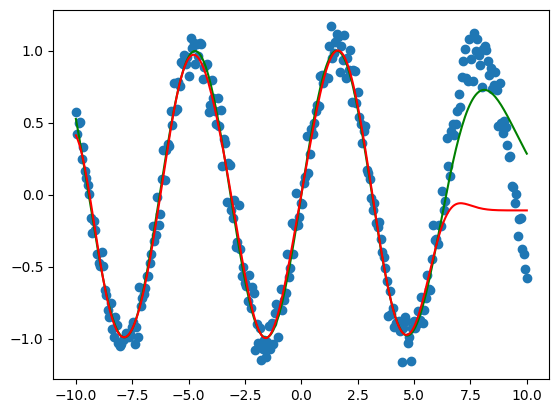

In [19]:
plt.scatter(x, y1)
plt.plot(x, model1.predict(x), c="g")
plt.plot(x, model_joint_1.predict(x), c="r")

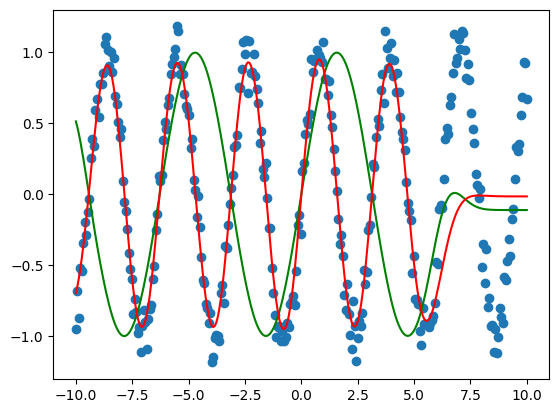

In [20]:
plt.scatter(x, y2)
plt.plot(x, model2.predict(x), c="g")
plt.plot(x, model_joint_2.predict(x), c="r")

In [25]:
1/0

ZeroDivisionError: division by zero

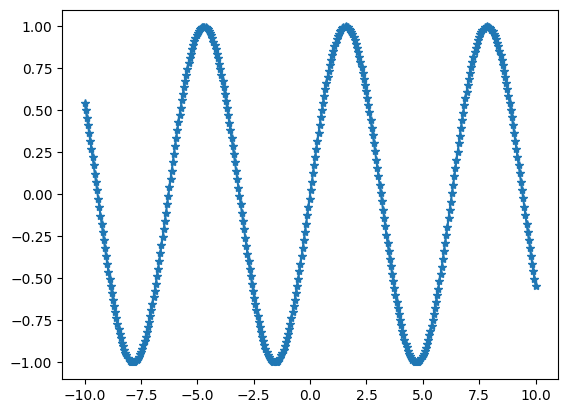

In [43]:
f = lambda x: np.sin(x)
x = np.linspace(-10, 10, 400)

plt.plot(x, f(x), "-*")

In [44]:
frequencies = np.linspace(0.01, 2, 50)
N_runs = 100
sigma = 1

In [46]:
results = defaultdict(list)

In [47]:
for freq in tqdm.tqdm(frequencies):
    temp_results = defaultdict(list)

    for i in range(N_runs):
        y1 = f(x) 
        y1_data = y1 + np.random.normal(0, sigma, len(y1))

        y2 = f(freq*x) 
        y2_data = y2 + np.random.normal(0, sigma, len(y2))

        # Joint
        best_pairwise_params = pairwise_paramsearch(x, y1_data, x, y2_data, 30)
        model_joint_1 = KRRWrapper(best_pairwise_params["bandwidth"], best_pairwise_params["reg1"])
        model_joint_2 = KRRWrapper(best_pairwise_params["bandwidth"], best_pairwise_params["reg1"])

        model_joint_1.fit(x, y1_data)
        model_joint_2.fit(x, y2_data)

        y_pred1 = model_joint_1.predict(x)
        y_pred2 = model_joint_2.predict(x)

        alpha1 = model_joint_1.model.alpha
        alpha2 = model_joint_2.model.alpha
        kernel = model_joint_2.model.kernels[0]

        ip1 = alpha1.T@kernel(x, x)@alpha1
        ip2 = alpha2.T@kernel(x, x)@alpha2
        ip12 = alpha1.T@kernel(x, x)@alpha2


        temp_results["MSE (Estimation)"].append(mean_squared_error(y_pred1, y1) + mean_squared_error(y_pred2, y2) )
        temp_results["MSE (Prediction)"].append(mean_squared_error(y_pred1, y1_data) + mean_squared_error(y_pred2, y2_data))
    
        temp_results["ip1"].append(ip1)
        temp_results["ip2"].append(ip2)
        temp_results["ip12"].append(ip12)

        temp_results["dist"].append(ip1 + ip2 - 2*ip12)
        temp_results["cosine"].append(ip12/np.sqrt(ip1*ip2))

    results["frequency"].append(freq)
    results["experiment"].append("Same Bandwidth")
    for k, v in temp_results.items():
        results[k].append(np.mean(v))

100%|██████████| 50/50 [1:26:20<00:00, 103.60s/it]


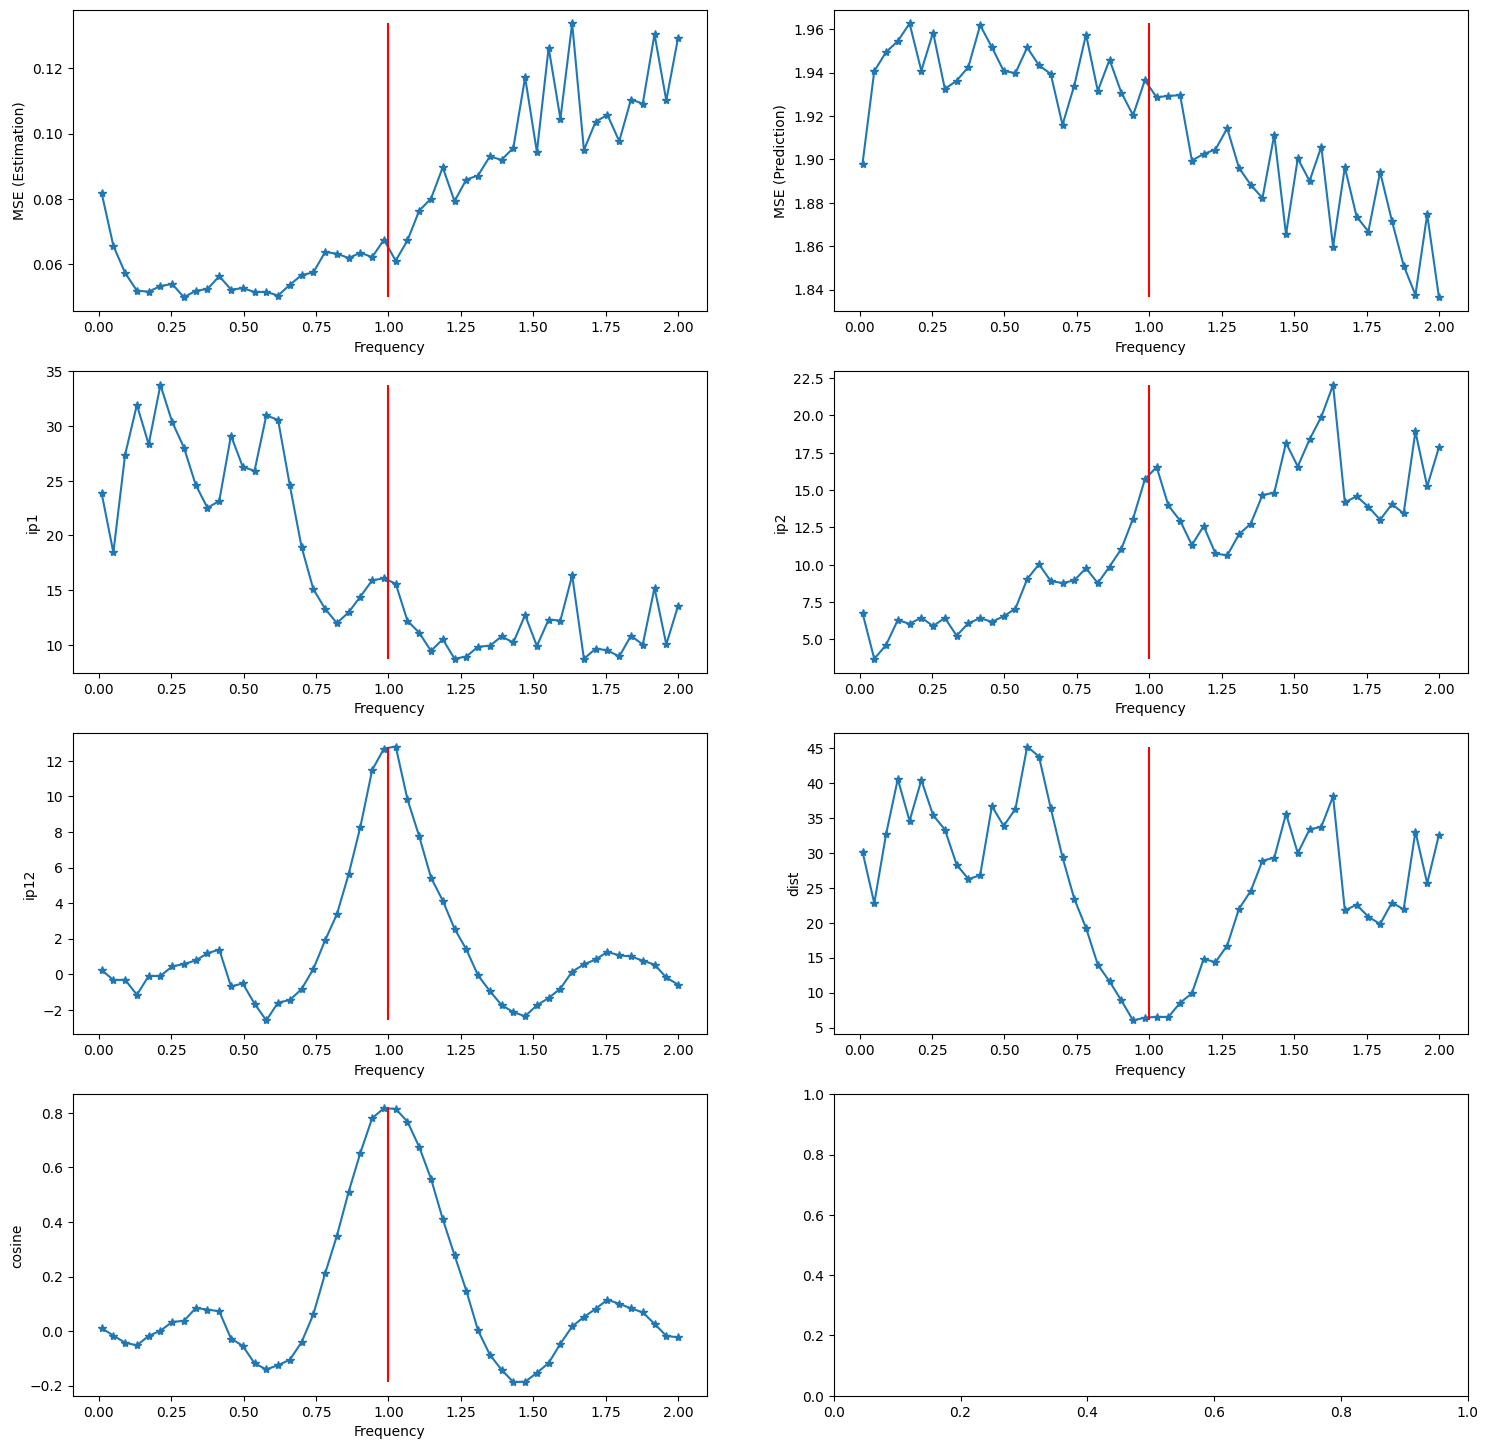

In [ ]:
df = pd.DataFrame(results)
df.to_csv("pairwise_test2.csv")
# Create figures
cols = [i for i in df.columns if i not in ["frequency", "experiment"]]
fig, axes = plt.subplots(ncols=2, nrows=int(np.ceil(len(cols)/2)), figsize=(18, 18))

axes = list(axes.flat)

for i in range(len(cols)):
    df_sub = df[df[cols[i]].abs() < 10000]
    axes[i].plot(df_sub["frequency"], df_sub[cols[i]], "-*")
    axes[i].set_xlabel("Frequency")
    axes[i].set_ylabel(cols[i])
    axes[i].vlines(1, df_sub[cols[i]].min(), df_sub[cols[i]].max(), color="red")

# plt.savefig("pairwise_test2.png")

# Gaus

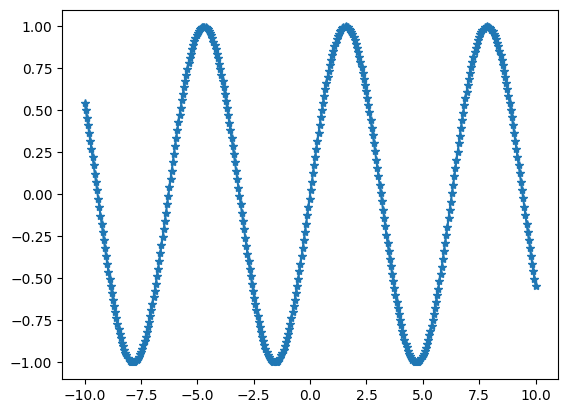

In [51]:
f = lambda x: np.sin(x)
x = np.linspace(-10, 10, 400)

plt.plot(x, f(x), "-*")

In [52]:
frequencies = np.linspace(0.01, 2, 50)
N_runs = 100
sigma = 1

In [53]:
results = defaultdict(list)

In [ ]:
for freq in tqdm.tqdm(frequencies):
    temp_results = defaultdict(list)

    for i in range(N_runs):
        y1 = f(x) 
        y1_data = y1 + np.random.normal(0, sigma, len(y1))

        y2 = f(freq*x) 
        y2_data = y2 + np.random.normal(0, sigma, len(y2))

        # DS1
        paramsearch.fit(x, y1)
        b1, _ = paramsearch.best_params.values()

        ''


        # Joint
        best_pairwise_params = pairwise_paramsearch(x, y1_data, x, y2_data, 30)
        model_joint_1 = KRRWrapper(best_pairwise_params["bandwidth"], best_pairwise_params["reg1"])
        model_joint_2 = KRRWrapper(best_pairwise_params["bandwidth"], best_pairwise_params["reg1"])

        model_joint_1.fit(x, y1_data)
        model_joint_2.fit(x, y2_data)

        y_pred1 = model_joint_1.predict(x)
        y_pred2 = model_joint_2.predict(x)

        alpha1 = model_joint_1.model.alpha
        alpha2 = model_joint_2.model.alpha
        kernel = model_joint_2.model.kernels[0]

        ip1 = alpha1.T@kernel(x, x)@alpha1
        ip2 = alpha2.T@kernel(x, x)@alpha2
        ip12 = alpha1.T@kernel(x, x)@alpha2


        temp_results["MSE (Estimation)"].append(mean_squared_error(y_pred1, y1) + mean_squared_error(y_pred2, y2) )
        temp_results["MSE (Prediction)"].append(mean_squared_error(y_pred1, y1_data) + mean_squared_error(y_pred2, y2_data))
    
        temp_results["ip1"].append(ip1)
        temp_results["ip2"].append(ip2)
        temp_results["ip12"].append(ip12)

        temp_results["dist"].append(ip1 + ip2 - 2*ip12)
        temp_results["cosine"].append(ip12/np.sqrt(ip1*ip2))

    results["frequency"].append(freq)
    results["experiment"].append("Same Bandwidth")
    for k, v in temp_results.items():
        results[k].append(np.mean(v))

  0%|          | 0/50 [00:00<?, ?it/s][W 2025-12-09 19:51:48,337] Trial 5 failed with parameters: {'bandwidth': 1.542187002753797, 'reg1': 0.0037527310819416137, 'reg2': 0.006971200903503901} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/james/Repo/PhD Repo/time_series_clustering/venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_515/4285977761.py", line 10, in objective
    return cross_val_score(model1, x1, y1) + cross_val_score(model2, x2, y2)
                                             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_515/3019964109.py", line 12, in cross_val_score
    model.fit(X_train, y_train)
  File "/home/james/Repo/PhD Repo/time_series_clustering/notebooks/helpers.py", line 129, in fit
    self.model.fit(X, y)
  File "/home/james/Repo/PhD Repo/time_series_clustering/time_ser

KeyboardInterrupt: 